# Tutorial1
We show how to train a profitable RL agent on portfolio managemnt with EIIE algorithm on US stock market.

## Step 1: Import Packages
Modify the system path and load the corresponding packages and functions

In [1]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
ROOT = os.path.dirname(os.path.abspath("."))
sys.path.append(ROOT)
import torch
import argparse
import os.path as osp
from mmcv import Config
from trademaster.utils import replace_cfg_vals
from trademaster.nets.builder import build_net
from trademaster.environments.builder import build_environment
from trademaster.datasets.builder import build_dataset
from trademaster.agents.builder import build_agent
from trademaster.optimizers.builder import build_optimizer
from trademaster.losses.builder import build_loss
from trademaster.trainers.builder import build_trainer
from trademaster.transition.builder import build_transition
from trademaster.utils import plot
from trademaster.utils import set_seed
set_seed(2025)

## Step 2: Load Configs
Load default config from the file `configs/portfolio_management/portfolio_management_mcad_eiie_eiie_adam_mse.py`

In [2]:
parser = argparse.ArgumentParser(description='Download Alpaca Datasets')
parser.add_argument("--config", default=osp.join(ROOT, "configs", "portfolio_management", "portfolio_management_mcad_eiie_eiie_adam_mse.py"),
                    help="download datasets config file path")
parser.add_argument("--task_name", type=str, default="train")

args, _= parser.parse_known_args()
cfg = Config.fromfile(args.config)
task_name = args.task_name
cfg = replace_cfg_vals(cfg)

In [3]:
cfg

Config (path: /home/chanwoo/projects/TradeMaster/configs/portfolio_management/portfolio_management_mcad_eiie_eiie_adam_mse.py): {'data': {'type': 'PortfolioManagementDataset', 'data_path': 'data/portfolio_management/mcad', 'train_path': 'data/portfolio_management/mcad/train.csv', 'valid_path': 'data/portfolio_management/mcad/valid.csv', 'test_path': 'data/portfolio_management/mcad/test.csv', 'tech_indicator_list': ['zopen', 'zhigh', 'zlow', 'zadjcp', 'zclose', 'zd_5', 'zd_10', 'zd_15', 'zd_20', 'zd_25', 'zd_30'], 'length_day': 10, 'initial_amount': 100000, 'transaction_cost_pct': 0.001, 'test_dynamic_path': 'data/portfolio_management/mcad/test_with_label.csv'}, 'environment': {'type': 'PortfolioManagementEIIEEnvironment'}, 'agent': {'type': 'PortfolioManagementEIIE', 'memory_capacity': 1000, 'gamma': 0.99, 'policy_update_frequency': 500}, 'trainer': {'type': 'PortfolioManagementEIIETrainer', 'epochs': 10, 'work_dir': 'work_dir/portfolio_management_mcad_eiie_eiie_adam_mse', 'if_remove':

## Step 3: Build Dataset

In [4]:
dataset = build_dataset(cfg)

## Step 4: Build Reinforcement Learning Environments

In [5]:
train_environment = build_environment(cfg, default_args=dict(dataset=dataset, task="train"))
valid_environment = build_environment(cfg, default_args=dict(dataset=dataset, task="valid"))
test_environment = build_environment(cfg, default_args=dict(dataset=dataset, task="test"))

In [6]:
train_environment.df.head()

,date,open,high,low,close,adjcp,volume,dividend,split,tic,...,zhigh,zlow,zadjcp,zclose,zd_5,zd_10,zd_15,zd_20,zd_25,zd_30
0,2007-02-14,82.050000,82.430000,82.050000,82.380000,52.627206,192600,0.0,1,ief,...,0.000607,-0.004006,0.005750,0.005750,-0.002989,-0.003934,-0.006289,-0.006142,-0.005711,-0.004601
0,2007-02-14,44.050000,44.710000,44.040000,44.600000,38.478699,133370000,0.0,1,qqq,...,0.002466,-0.012556,0.016872,0.016872,-0.011435,-0.010628,-0.013647,-0.013800,-0.009067,-0.010448
0,2007-02-14,66.270000,66.660000,65.970000,66.370000,66.370000,4176806,0.0,1,gld,...,0.004369,-0.006027,0.008050,0.008050,-0.007021,-0.016498,-0.021918,-0.027972,-0.036752,-0.043895
0,2007-02-14,79.930000,80.050000,79.930000,80.040000,59.645373,596200,0.0,1,shy,...,0.000125,-0.001374,0.002254,0.002254,-0.001524,-0.002036,-0.002774,-0.003136,-0.003413,-0.003440
0,2007-02-14,144.800003,145.899994,144.779999,145.610001,103.200969,66039400,0.0,1,spy,...,0.001992,-0.005700,0.006567,0.006567,-0.007376,-0.006215,-0.011043,-0.012939,-0.014507,-0.017174


## Step 5: Build Net 
Update information on the state and action dimension. Crreate networks and optimizer for EIIE.

In [7]:
action_dim = train_environment.action_dim # 29
state_dim = train_environment.state_dim # 11
input_dim = len(train_environment.tech_indicator_list)
time_steps = train_environment.time_steps

cfg.act.update(dict(input_dim=input_dim, time_steps=time_steps))
cfg.cri.update(dict(input_dim=input_dim, action_dim= action_dim, time_steps=time_steps))

act = build_net(cfg.act)
cri = build_net(cfg.cri)
act_optimizer = build_optimizer(cfg, default_args=dict(params=act.parameters()))
cri_optimizer = build_optimizer(cfg, default_args=dict(params=cri.parameters()))

## Step 6: Build Loss Function

In [8]:
criterion = build_loss(cfg)

## Step 7: Build Transition

In [9]:
transition = build_transition(cfg)


## Step 8: Build Agent

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
agent = build_agent(cfg, default_args=dict(action_dim=action_dim,state_dim=state_dim,time_steps = time_steps,act=act,cri=cri,act_optimizer=act_optimizer,cri_optimizer = cri_optimizer,criterion=criterion,transition = transition,device = device))

## Step 9: Build Trainer
Build trainer from config and create work directionary to save the result, model and config

In [11]:
trainer = build_trainer(cfg, default_args=dict(train_environment=train_environment,valid_environment=valid_environment,test_environment=test_environment,agent=agent,device=device))
work_dir = os.path.join(ROOT, cfg.trainer.work_dir)

if not os.path.exists(work_dir):
    os.makedirs(work_dir)
cfg.dump(osp.join(work_dir, osp.basename(args.config)))

## Step 10: RL Agent Training
Train the EIIE agent based on the config and save results in workdir

In [12]:
trainer.train_and_valid()

Train Episode: [1/10]
+--------------+-------------+------------+--------------+
| Total Return | Sharp Ratio | Volatility | Max Drawdown |
+--------------+-------------+------------+--------------+
|    0nan%     |     0nan    |   0nan%    |  5.263763%   |
+--------------+-------------+------------+--------------+
Valid Episode: [1/10]
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+------------+--------------+
|                                                                                                          Total Return                                                                                                         | Sharp Ratio | Volatility | Max Drawdown |
+----------------------------------------------------------------------------------------------------------------------------

KeyboardInterrupt: 

## Step 11: RL Agent Testing

Test Best Episode
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+------------+--------------+
|                                                                                                             Total Return                                                                                                            | Sharp Ratio | Volatility | Max Drawdown |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+------------+--------------+
| 22932050714346497160743129953473732398424931394516713218598252957973900486758912717968711750629328433451880584181021330512539984371141266609195820134743504194

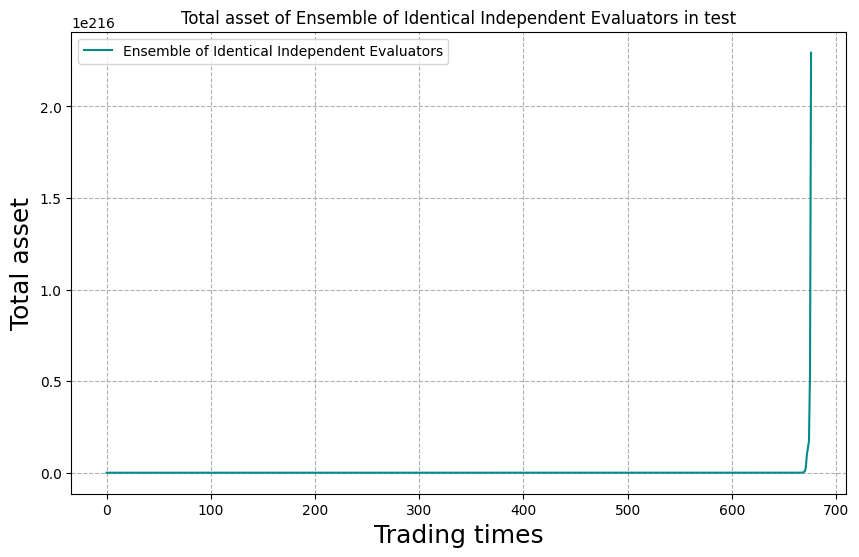

In [27]:
trainer.test();

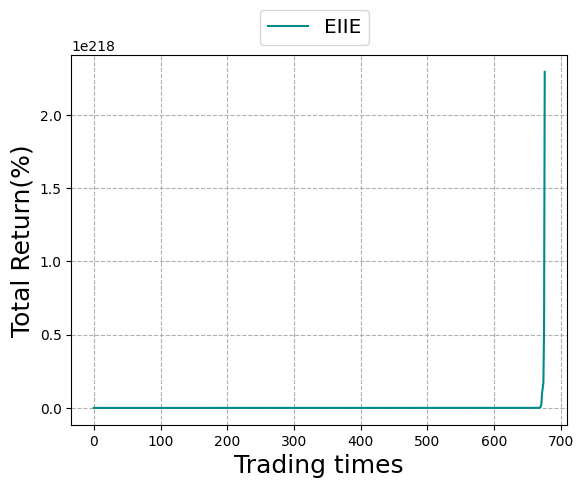

In [14]:
plot(trainer.test_environment.save_asset_memory(),alg="EIIE")